##### ARTI 560 - Computer Vision

## Semantic Segmentation

### Introduction

This notebook introduces semantic segmentation using the Oxford Pets dataset. Semantic segmentation assigns a class label to each pixel in an image, for example distinguishing the pet from the background.

We will use TensorFlow and Keras to:

1. Load and preprocess data
2. Visualize images and masks
3. Build a simple U-Net model
4. Train the model
5. Evaluate using Intersection over Union (IoU) and visualize predictions

In [1]:
# Import Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load the Dataset
IMG_SIZE = 128
BATCH_SIZE = 8

(ds_train, ds_test), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train", "test"],
    with_info=True,
    as_supervised=False
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.1CZSWG_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.1CZSWG_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


In [5]:
# Print the shape of 10 random images
for i, sample in enumerate(ds_train.shuffle(1000).take(5)):
    image = sample['image']
    
    print(f"Image {i+1}:")
    print("Shape:", image.shape)
    
    # Extract dimensions
    height, width, channels = image.shape
    print("-" * 40)

Image 1:
Shape: (333, 500, 3)
----------------------------------------
Image 2:
Shape: (229, 300, 3)
----------------------------------------
Image 3:
Shape: (236, 300, 3)
----------------------------------------
Image 4:
Shape: (334, 500, 3)
----------------------------------------
Image 5:
Shape: (333, 500, 3)
----------------------------------------


In [ ]:
# Print Segmentation Mask Classes
def find_min_max(dataset):
    min_val = tf.constant(100, dtype=tf.int32)
    max_val = tf.constant(-100, dtype=tf.int32)

    for sample in dataset:
        mask = tf.cast(sample['segmentation_mask'], tf.int32)

        min_val = tf.minimum(min_val, tf.reduce_min(mask))
        max_val = tf.maximum(max_val, tf.reduce_max(mask))

    return min_val.numpy(), max_val.numpy()

# usage
min_class, max_class = find_min_max(ds_train)

print("Min class:", min_class)
print("Max class:", max_class)

Min class: 1
Max class: 3


When inspecting the segmentation masks in the **Oxford-IIIT Pet Dataset**, we find:

```
Min class: 1
Max class: 3
```
 #### Class Mapping
| Mask Value | Meaning                     |
| ---------- | --------------------------- |
| 1          | Pet (cat or dog)            |
| 2          | Background                  |
| 3          | Outline / border around pet |

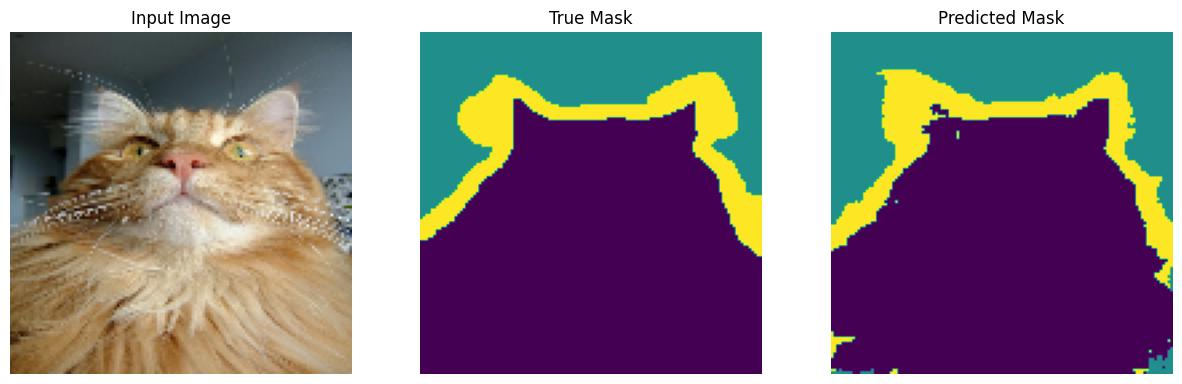

**Note:** The dataset has 37 pet breeds, but this number refers to the classification labels, not segmentation classes.

#### Preprocessing for Training

Most deep learning models (e.g., U-Net, Mask R-CNN) expect zero-based labels, so we will substract the mask by 1.
`mask -= 1`

After this transformation:

| Mask Value | Meaning                     |
| ---------- | --------------------------- |
| 0          | Pet                         |
| 1          | Background                  |
| 2          | Outline / border around pet |



In [11]:
# Preprocessing Functions
def normalize(image, mask):
    image = tf.cast(image, tf.float32) / 255.0
    mask -= 1  # labels 1,2,3 -> 0,1,2
    return image, mask


def load_image(datapoint):
    image = datapoint['image']
    mask = datapoint['segmentation_mask']

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE), method='nearest')

    return normalize(image, mask)

### Why we use nearest method for resizing masks?

- The default method for upscaling is **Bilinear interpolation** which is weighted average of the 4 nearest pixels around the target location when resizing an image.
- Bilinear interpolation would produce fractions like 0.5, 1.25.
- Masks have discrete class IDs, e.g., 0, 1, 2:

Solution: Use **nearest neighbor**, which picks the closest original pixel instead of averaging.

In [8]:
tf.image.resize?

Signature: tf.image.resize(images, size, method='bilinear', preserve_aspect_ratio=False, antialias=False, name=None)
Docstring:
Resize `images` to `size` using the specified `method`.

Resized images will be distorted if their original aspect ratio is not
the same as `size`.  To avoid distortions see
`tf.image.resize_with_pad`.

>>> image = tf.constant([
...  [1,0,0,0,0],
...  [0,1,0,0,0],
...  [0,0,1,0,0],
...  [0,0,0,1,0],
...  [0,0,0,0,1],
... ])
>>> # Add "batch" and "channels" dimensions
>>> image = image[tf.newaxis, ..., tf.newaxis]
>>> image.shape.as_list()  # [batch, height, width, channels]
[1, 5, 5, 1]
>>> tf.image.resize(image, [3,5])[0,...,0].numpy()
array([[0.6666667, 0.3333333, 0.       , 0.       , 0.       ],
       [0.       , 0.       , 1.       , 0.       , 0.       ],
       [0.       , 0.       , 0.       , 0.3333335, 0.6666665]],
      dtype=float32)

It works equally well with a single image instead of a batch of images:

>>> tf.image.resize(image[0], [3,5]).shap

In [12]:
# Build Dataset Pipeline
train_dataset = ds_train.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = ds_test.map(load_image).batch(BATCH_SIZE)

In [13]:
# Visualization Function

def display_sample(image, mask):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.title("Image")
    plt.imshow(image)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Mask")
    plt.imshow(mask[..., 0])
    plt.axis('off')
    plt.show()

In [14]:
# Build U-Net Model
def unet_model(output_channels): # output_channels is the number of classes in segmentation (e.g., 3 for pet/background/outline)
    inputs = layers.Input(shape=[IMG_SIZE, IMG_SIZE, 3])

    # Encoder (downsampling)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D()(c2)

    b1 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)

    # Decoder (upsampling)
    u1 = layers.UpSampling2D()(b1)
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c3)
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(u2)

    outputs = layers.Conv2D(output_channels, 1, activation='softmax')(c4) #reduce the number of channels to match the number of classes

    return keras.Model(inputs=inputs, outputs=outputs)

model = unet_model(output_channels=3)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 3)    │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,723 (182.51 KB)

 Trainable params: 46,723 (182.51 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train the Model
EPOCHS = 5
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS
)

Epoch 1/5
460/460 ━━━━━━━━━━━━━━━━━━━━ 318s 677ms/step - accuracy: 0.6448 - loss: 0.7828 - val_accuracy: 0.6767 - val_loss: 0.7367
Epoch 2/5
460/460 ━━━━━━━━━━━━━━━━━━━━ 308s 661ms/step - accuracy: 0.7096 - loss: 0.6762 - val_accuracy: 0.7326 - val_loss: 0.6406
Epoch 3/5
460/460 ━━━━━━━━━━━━━━━━━━━━ 315s 679ms/step - accuracy: 0.7308 - loss: 0.6365 - val_accuracy: 0.7207 - val_loss: 0.6565
Epoch 4/5
460/460 ━━━━━━━━━━━━━━━━━━━━ 321s 677ms/step - accuracy: 0.7405 - loss: 0.6183 - val_accuracy: 0.7211 - val_loss: 0.6439
Epoch 5/5
460/460 ━━━━━━━━━━━━━━━━━━━━ 300s 646ms/step - accuracy: 0.7514 - loss: 0.5977 - val_accuracy: 0.7605 - val_loss: 0.5803


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step


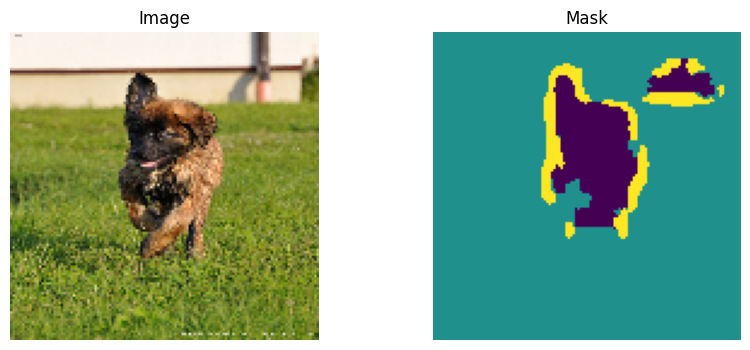

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


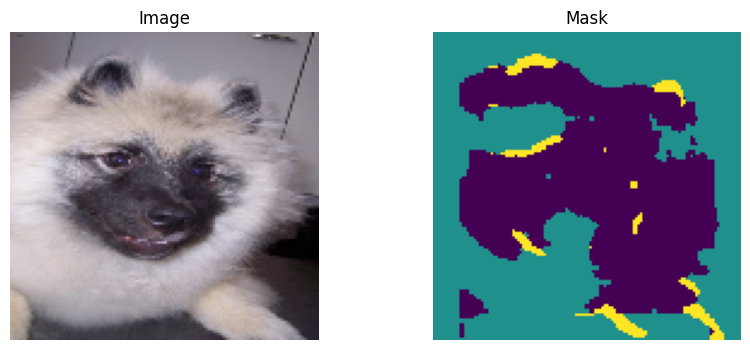

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


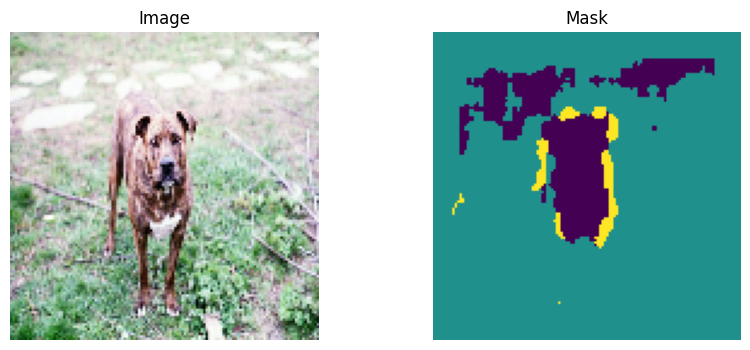

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


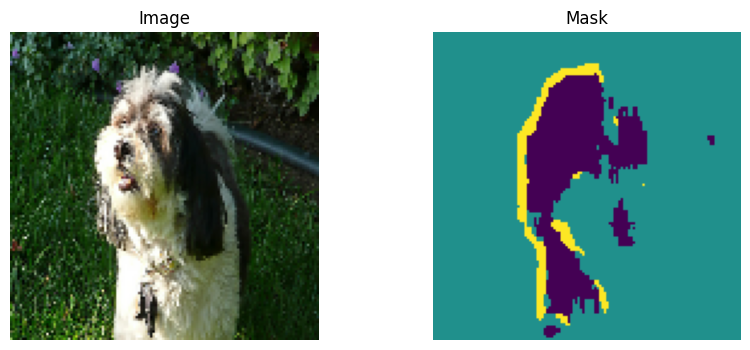

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


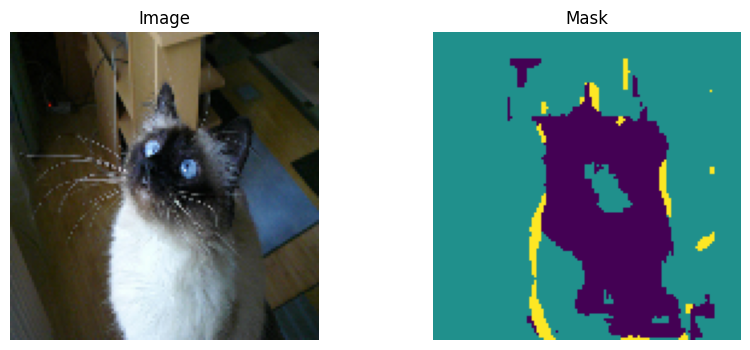

In [16]:
# Predictions and Visualization
def create_mask(pred_mask):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    return pred_mask

for image, mask in test_dataset.take(5):
    pred_mask = model.predict(image)
    pred_mask = create_mask(pred_mask)
    display_sample(image[0], pred_mask[0])

In [10]:
# Evaluation with Intersection over Union (IoU)
def compute_iou(y_true, y_pred, num_classes=3):
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])
    ious = []
    for i in range(num_classes):
        intersection = tf.reduce_sum(tf.cast((y_true == i) & (y_pred == i), tf.float32))
        union = tf.reduce_sum(tf.cast((y_true == i) | (y_pred == i), tf.float32))
        iou = intersection / (union + 1e-7)
        ious.append(iou)
    return tf.reduce_mean(ious)

ious = []
for image, mask in test_dataset:
    pred_mask = model.predict(image)
    pred_mask = create_mask(pred_mask)
    iou = compute_iou(mask, pred_mask)
    ious.append(iou)

mean_iou = tf.reduce_mean(ious)
print(f"Mean IoU on test dataset: {mean_iou*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 